    Size |    CPU (s) |    GPU (s) |    Speedup |  Correct
--------------------------------------------------------------
     100 |     0.3863 |     0.1264 |       3.06 |     True
     480 |    44.9514 |     0.0058 |    7775.79 |     True
     860 |   256.5394 |     0.0316 |    8122.16 |     True
    1240 |   793.8334 |     0.0941 |    8431.66 |     True
    1620 |  1772.0199 |     0.1822 |    9725.72 |     True
    2000 |  3346.4240 |     0.3077 |   10877.28 |     True


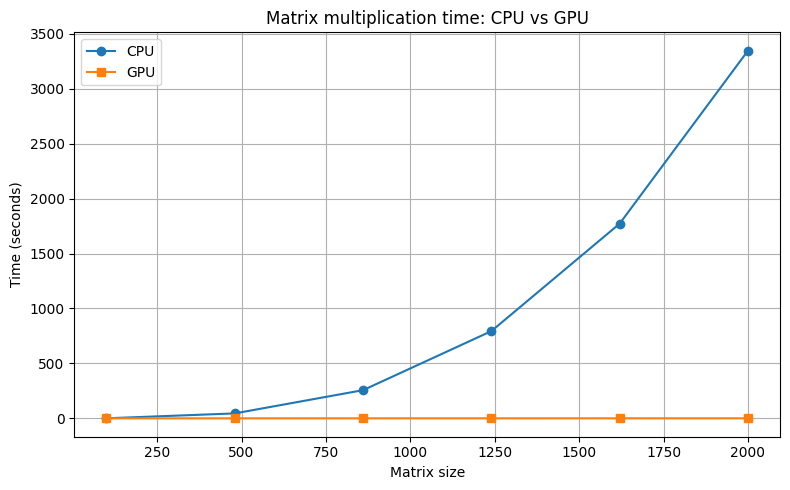

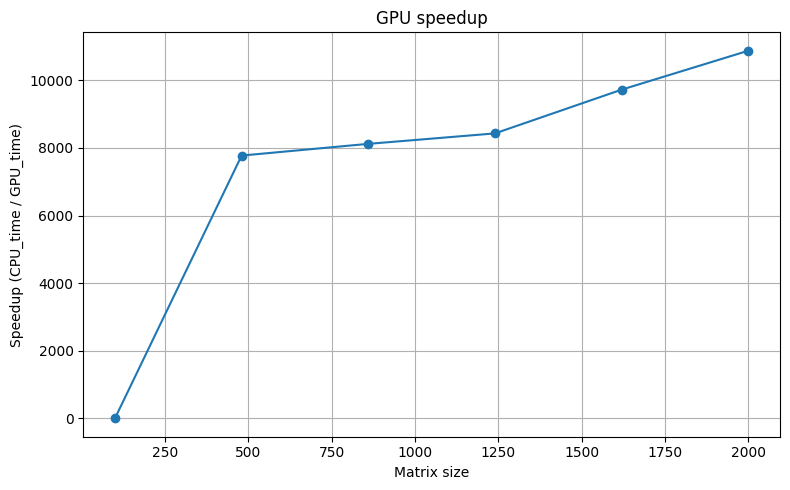

In [7]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda
import warnings
from numba.core.errors import NumbaPerformanceWarning

warnings.simplefilter('ignore', category=NumbaPerformanceWarning)


# =========================
# CPU version
# =========================
def matmul_cpu(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    n, m = a.shape
    m2, k = b.shape
    if m != m2:
        raise ValueError("Incompatible matrix sizes")

    c = np.zeros((n, k), dtype=np.float32)

    for i in range(n):
        for j in range(k):
            s = 0.0
            for t in range(m):
                s += a[i, t] * b[t, j]
            c[i, j] = s

    return c


# =========================
# GPU kernel (CUDA)
# =========================
@cuda.jit
def matmul_gpu_kernel(a, b, c):
    row, col = cuda.grid(2)

    if row < c.shape[0] and col < c.shape[1]:
        tmp = 0.0
        for k in range(a.shape[1]):
            tmp += a[row, k] * b[k, col]
        c[row, col] = tmp


def matmul_gpu(a: np.ndarray, b: np.ndarray, threads_per_block=(16, 16)):
    n, m = a.shape
    m2, k = b.shape
    if m != m2:
        raise ValueError("Incompatible matrix sizes")

    a_device = cuda.to_device(a)
    b_device = cuda.to_device(b)
    c_device = cuda.device_array((n, k), dtype=np.float32)

    blocks_per_grid_x = math.ceil(n / threads_per_block[0])
    blocks_per_grid_y = math.ceil(k / threads_per_block[1])
    blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

    start = time.perf_counter()
    matmul_gpu_kernel[blocks_per_grid, threads_per_block](a_device, b_device, c_device)
    cuda.synchronize()
    gpu_time = time.perf_counter() - start

    c = c_device.copy_to_host()
    return c, gpu_time


# =========================
# Utilities
# =========================
def check_correctness(x: np.ndarray, y: np.ndarray, eps: float = 1e-3) -> bool:
    return np.allclose(x, y, atol=eps, rtol=eps)


def benchmark_cpu(a: np.ndarray, b: np.ndarray):
    start = time.perf_counter()
    c = matmul_cpu(a, b)
    cpu_time = time.perf_counter() - start
    return c, cpu_time


def run_experiment(sizes):
    results = []

    print(f"{'Size':>8} | {'CPU (s)':>10} | {'GPU (s)':>10} | {'Speedup':>10} | {'Correct':>8}")
    print("-" * 62)

    for n in sizes:
        a = np.random.rand(n, n).astype(np.float32)
        b = np.random.rand(n, n).astype(np.float32)

        cpu_result, cpu_time = benchmark_cpu(a, b)
        gpu_result, gpu_time = matmul_gpu(a, b)

        ok = check_correctness(cpu_result, gpu_result)
        speedup = cpu_time / gpu_time if gpu_time > 0 else float("inf")

        results.append({
            "size": n,
            "cpu_time": cpu_time,
            "gpu_time": gpu_time,
            "speedup": speedup,
            "correct": ok
        })

        print(f"{n:8d} | {cpu_time:10.4f} | {gpu_time:10.4f} | {speedup:10.2f} | {str(ok):>8}")

    return results


# =========================
# Plotting
# =========================
def plot_results(results):
    sizes = [r["size"] for r in results]
    cpu_times = [r["cpu_time"] for r in results]
    gpu_times = [r["gpu_time"] for r in results]
    speedups = [r["speedup"] for r in results]

    # Graph 1: execution time
    plt.figure(figsize=(8, 5))
    plt.plot(sizes, cpu_times, marker='o', label='CPU')
    plt.plot(sizes, gpu_times, marker='s', label='GPU')
    plt.xlabel('Matrix size')
    plt.ylabel('Time (seconds)')
    plt.title('Matrix multiplication time: CPU vs GPU')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('execution_time.png')
    plt.show()

    # Graph 2: speedup
    plt.figure(figsize=(8, 5))
    plt.plot(sizes, speedups, marker='o')
    plt.xlabel('Matrix size')
    plt.ylabel('Speedup (CPU_time / GPU_time)')
    plt.title('GPU speedup')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('speedup.png')
    plt.show()


if __name__ == "__main__":
    if not cuda.is_available():
        print("CUDA is not available. Check NVIDIA GPU, driver and CUDA setup.")
    else:
        sizes = [100, 480, 860, 1240, 1620, 2000]
        results = run_experiment(sizes)
        plot_results(results)